# Bias-Aware ML Pipeline for Stress Prediction
### Addresses: Class Imbalance, Data Leakage, and Fairness Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Dataset

In [2]:
df = pd.read_csv('../Dataset/final.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2839, 42)


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,acc_z_std,...,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,ecg_peak_freq,resp_peak_freq,temp_slope,eda_slope,label,subject
0,0.872800,0.024465,0.5070,1.1758,-0.132889,0.031347,-0.4014,0.1010,-0.284486,0.047498,...,0.929273,0.025727,0.522995,1.506039,2.200000,0.433333,-0.000012,-0.000033,0,2
1,0.875788,0.059040,0.4826,1.2712,-0.120982,0.078589,-0.4616,0.1268,-0.245599,0.127737,...,0.929947,0.056012,0.496726,1.303793,2.600000,0.066667,-0.000037,-0.000015,0,2
2,0.861583,0.021205,0.7454,1.1624,-0.156330,0.020616,-0.2042,-0.1002,-0.316530,0.031280,...,0.931918,0.018373,0.785213,1.185841,1.300000,0.100000,0.000004,0.000032,0,2
3,0.862690,0.009803,0.7906,0.9224,-0.181321,0.022755,-0.2394,-0.1370,-0.306185,0.014533,...,0.933610,0.007607,0.882272,0.981359,2.466667,0.366667,0.000003,-0.000026,0,2
4,0.857272,0.006321,0.8050,0.9246,-0.188318,0.022537,-0.2520,-0.1382,-0.320673,0.011200,...,0.934800,0.005797,0.882175,0.996625,1.200000,0.400000,-0.000011,-0.000036,0,2


## 2. Keep Subject Column for Group-Aware Splitting
**Critical Fix:** We keep the subject column to prevent data leakage by ensuring no subject appears in both train and test sets.

In [3]:
# Check subject distribution
print("Samples per subject:")
print(df['subject'].value_counts())

Samples per subject:
subject
6     232
3     214
4     210
5     205
2     201
17    193
16    183
14    181
13    180
10    179
8     177
9     172
7     171
15    171
11    170
Name: count, dtype: int64


## 3. Filter and Recode Labels

In [4]:
# Keep only relevant labels
accept_label = [1, 2, 3, 4]
df = df[df["label"].isin(accept_label)]
print("After filtering:")
print(df["label"].value_counts())

After filtering:
label
1    581
4    387
2    326
3    180
Name: count, dtype: int64


In [5]:
# Recode: 2 -> 1 (stress), [1,3,4] -> 0 (no stress)
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["label"] = df["label"].apply(apply_target)
print("\nAfter recoding:")
print(df["label"].value_counts())
print(f"\nClass imbalance ratio: {df['label'].value_counts()[0] / df['label'].value_counts()[1]:.2f}:1")


After recoding:
label
0    1148
1     326
Name: count, dtype: int64

Class imbalance ratio: 3.52:1


## 4. Group-Aware Train-Test Split
**Prevents Data Leakage:** Split by subject, not by sample.

In [6]:
from sklearn.model_selection import train_test_split

# Get unique subjects
unique_subjects = df['subject'].unique()

# Split subjects (not samples) into train/test
train_subjects, test_subjects = train_test_split(
    unique_subjects, 
    test_size=0.2, 
    random_state=42,
    stratify=None  # Can't stratify by subject easily
)

print(f"Train subjects: {len(train_subjects)}")
print(f"Test subjects: {len(test_subjects)}")

# Split data based on subjects
train_df = df[df['subject'].isin(train_subjects)]
test_df = df[df['subject'].isin(test_subjects)]

print(f"\nTrain samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

# Verify no overlap
train_subs = set(train_df['subject'].unique())
test_subs = set(test_df['subject'].unique())
print(f"\nSubject overlap: {len(train_subs & test_subs)} (should be 0)")

Train subjects: 12
Test subjects: 3

Train samples: 1181
Test samples: 293

Subject overlap: 0 (should be 0)


In [7]:
# Check class distribution in train and test
print("Train class distribution:")
print(train_df['label'].value_counts())
print(f"Ratio: {train_df['label'].value_counts()[0] / train_df['label'].value_counts()[1]:.2f}:1\n")

print("Test class distribution:")
print(test_df['label'].value_counts())
print(f"Ratio: {test_df['label'].value_counts()[0] / test_df['label'].value_counts()[1]:.2f}:1")

Train class distribution:
label
0    919
1    262
Name: count, dtype: int64
Ratio: 3.51:1

Test class distribution:
label
0    229
1     64
Name: count, dtype: int64
Ratio: 3.58:1


## 5. Prepare Features and Labels

In [8]:
# Now drop subject column for modeling
X_train = train_df.drop(['label', 'subject'], axis=1)
y_train = train_df['label']

X_test = test_df.drop(['label', 'subject'], axis=1)
y_test = test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1181, 40)
X_test shape: (293, 40)


## 6. Handle Class Imbalance with SMOTE
**Only on training data** - test set remains original for fair evaluation.

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_res.value_counts())
print(f"Balanced ratio: 1:1")

After SMOTE:
label
0    919
1    919
Name: count, dtype: int64
Balanced ratio: 1:1


## 7. Model Training with Cross-Validation
**Stratified Group K-Fold** ensures proper evaluation.

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Prepare data with subject for Group K-Fold
train_with_subject = train_df.copy()
groups = train_with_subject['subject'].values

X_full = train_with_subject.drop(['label', 'subject'], axis=1).values
y_full = train_with_subject['label'].values

# Stratified Group K-Fold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
cv_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_full, y_full, groups)):
    
    X_tr, X_val = X_full[train_idx], X_full[val_idx]
    y_tr, y_val = y_full[train_idx], y_full[val_idx]

    # Apply SMOTE only on training data
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
    
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.2,
        subsample=0.7,
        colsample_bytree=0.7,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        eval_metric='logloss',
        objective='binary:logistic',
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_tr_res, y_tr_res, verbose=False)
    preds = model.predict(X_val)
    
    cv_metrics['accuracy'].append(accuracy_score(y_val, preds))
    cv_metrics['precision'].append(precision_score(y_val, preds))
    cv_metrics['recall'].append(recall_score(y_val, preds))
    cv_metrics['f1'].append(f1_score(y_val, preds))
    cv_scores.append(accuracy_score(y_val, preds))

print("=" * 50)
print("Stratified Group K-Fold Cross-Validation Results")
print("=" * 50)
for metric, scores in cv_metrics.items():
    print(f"{metric.capitalize():12}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

Stratified Group K-Fold Cross-Validation Results
Accuracy    : 0.8970 (+/- 0.0472)
Precision   : 0.8070 (+/- 0.1141)
Recall      : 0.7335 (+/- 0.2081)
F1          : 0.7451 (+/- 0.1357)


## 8. Train Final Model

In [11]:
# Train on full SMOTE-balanced training data
final_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.2,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    eval_metric='logloss',
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_res, y_train_res, verbose=False)
print("Final model trained on balanced training data")

Final model trained on balanced training data


## 9. Evaluate on ORIGINAL (Unbalanced) Test Set
**Fair evaluation** - no resampling on test data.

Evaluation on ORIGINAL Test Set (Unbalanced)
Accuracy: 0.8737

Classification Report:
               precision    recall  f1-score   support

No Stress (0)       0.92      0.92      0.92       229
   Stress (1)       0.71      0.72      0.71        64

     accuracy                           0.87       293
    macro avg       0.81      0.82      0.82       293
 weighted avg       0.87      0.87      0.87       293



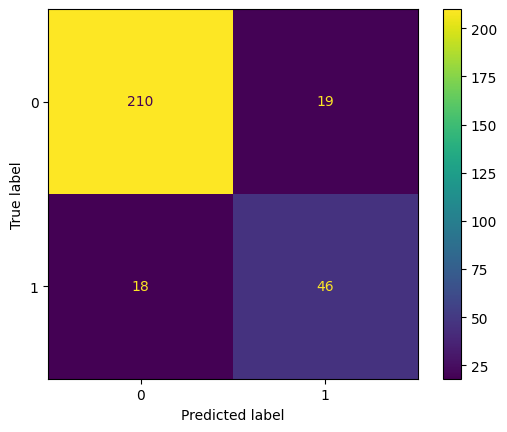

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_pred = final_model.predict(X_test)

print("=" * 50)
print("Evaluation on ORIGINAL Test Set (Unbalanced)")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Stress (0)', 'Stress (1)']))

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
# cm = confusion_matrix(y_test_res, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

## 10. Fairness and Bias Analysis
**Key metrics for detecting model bias**

In [14]:
# Calculate fairness metrics
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Metrics by class
tpr_class0 = tn / (tn + fp)  # True Negative Rate for Class 0
tpr_class1 = tp / (tp + fn)  # True Positive Rate for Class 1 (Recall)
ppv_class0 = tn / (tn + fn)  # Negative Predictive Value
ppv_class1 = tp / (tp + fp)  # Positive Predictive Value (Precision)

print("=" * 50)
print("FAIRNESS METRICS")
print("=" * 50)
print(f"\n--- Class 0 (No Stress) ---")
print(f"True Negative Rate (Specificity): {tpr_class0:.4f}")
print(f"Negative Predictive Value:        {ppv_class0:.4f}")
print(f"\n--- Class 1 (Stress) ---")
print(f"True Positive Rate (Recall):      {tpr_class1:.4f}")
print(f"Positive Predictive Value:        {ppv_class1:.4f}")

# Fairness gap analysis
print("\n" + "=" * 50)
print("FAIRNESS GAP ANALYSIS")
print("=" * 50)
recall_gap = abs(tpr_class1 - tpr_class0)
precision_gap = abs(ppv_class1 - ppv_class0)

print(f"\nRecall Gap (|TPR_class1 - TPR_class0|): {recall_gap:.4f}")
print(f"  - Ideal: 0.0 (equal opportunity)")
print(f"  - Acceptable: < 0.1")
print(f"  - Status: {'✅ PASS' if recall_gap < 0.1 else '⚠️ REVIEW'}")

print(f"\nPrecision Gap (|PPV_class1 - PPV_class0|): {precision_gap:.4f}")
print(f"  - Ideal: 0.0 (predictive parity)")
print(f"  - Acceptable: < 0.1")
print(f"  - Status: {'✅ PASS' if precision_gap < 0.1 else '⚠️ REVIEW'}")

FAIRNESS METRICS

--- Class 0 (No Stress) ---
True Negative Rate (Specificity): 0.9170
Negative Predictive Value:        0.9211

--- Class 1 (Stress) ---
True Positive Rate (Recall):      0.7188
Positive Predictive Value:        0.7077

FAIRNESS GAP ANALYSIS

Recall Gap (|TPR_class1 - TPR_class0|): 0.1983
  - Ideal: 0.0 (equal opportunity)
  - Acceptable: < 0.1
  - Status: ⚠️ REVIEW

Precision Gap (|PPV_class1 - PPV_class0|): 0.2134
  - Ideal: 0.0 (predictive parity)
  - Acceptable: < 0.1
  - Status: ⚠️ REVIEW


In [15]:
# Error analysis by class
print("=" * 50)
print("ERROR RATE ANALYSIS")
print("=" * 50)

fpr_class0 = fp / (fp + tn)  # False Positive Rate for Class 0
fnr_class1 = fn / (fn + tp)  # False Negative Rate for Class 1

print(f"\nFalse Positive Rate (Class 0 misclassified as Stress): {fpr_class0:.4f}")
print(f"False Negative Rate (Class 1 misclassified as No Stress): {fnr_class1:.4f}")

error_gap = abs(fpr_class0 - fnr_class1)
print(f"\nError Rate Gap: {error_gap:.4f}")
print(f"  - Ideal: 0.0 (equal error rates)")
print(f"  - Acceptable: < 0.1")
print(f"  - Status: {'✅ PASS' if error_gap < 0.1 else '⚠️ REVIEW'}")

ERROR RATE ANALYSIS

False Positive Rate (Class 0 misclassified as Stress): 0.0830
False Negative Rate (Class 1 misclassified as No Stress): 0.2812

Error Rate Gap: 0.1983
  - Ideal: 0.0 (equal error rates)
  - Acceptable: < 0.1
  - Status: ⚠️ REVIEW


## 11. Feature Importance Analysis

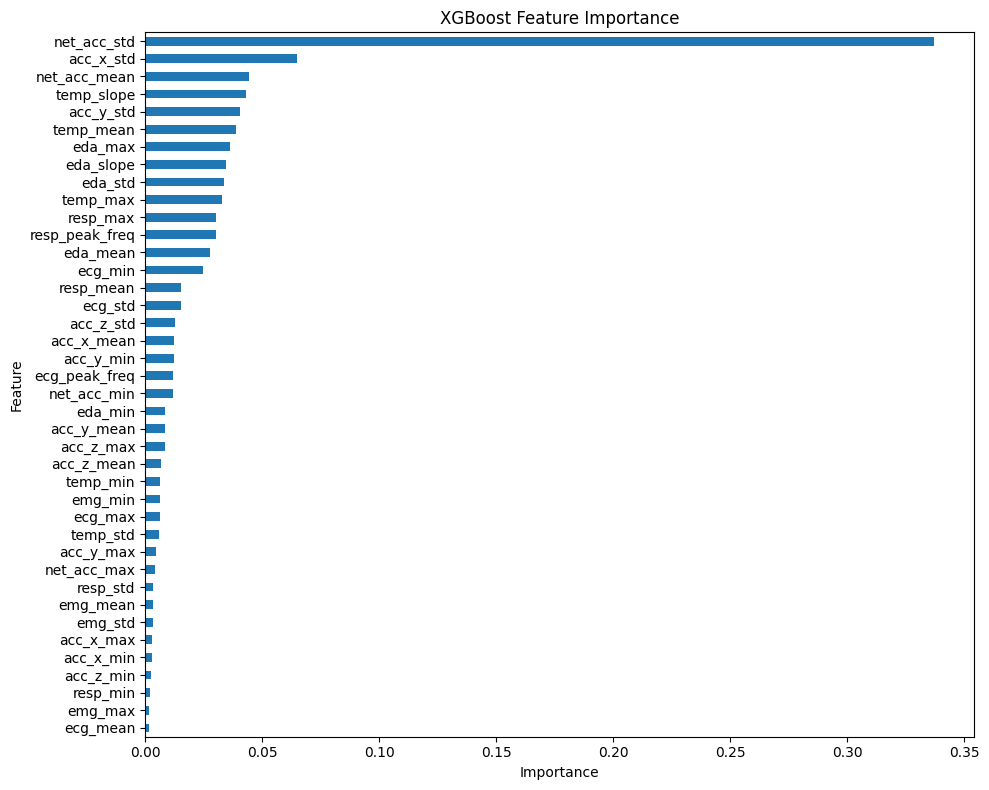

Top 10 Most Important Features:
     feature  importance
    temp_max    0.032760
     eda_std    0.033759
   eda_slope    0.034696
     eda_max    0.036044
   temp_mean    0.038821
   acc_y_std    0.040456
  temp_slope    0.043185
net_acc_mean    0.044373
   acc_x_std    0.064843
 net_acc_std    0.337343


In [16]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance_df.plot.barh(x='feature', y='importance', ax=ax, legend=False)
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

# Top 10 features
print("Top 10 Most Important Features:")
print(importance_df.tail(10).to_string(index=False))

## 12. SHAP Analysis for Model Interpretability

c:\Users\Yadnesh\OneDrive\Desktop\codes\XAI_For_Stress_and_Mental_Health_Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


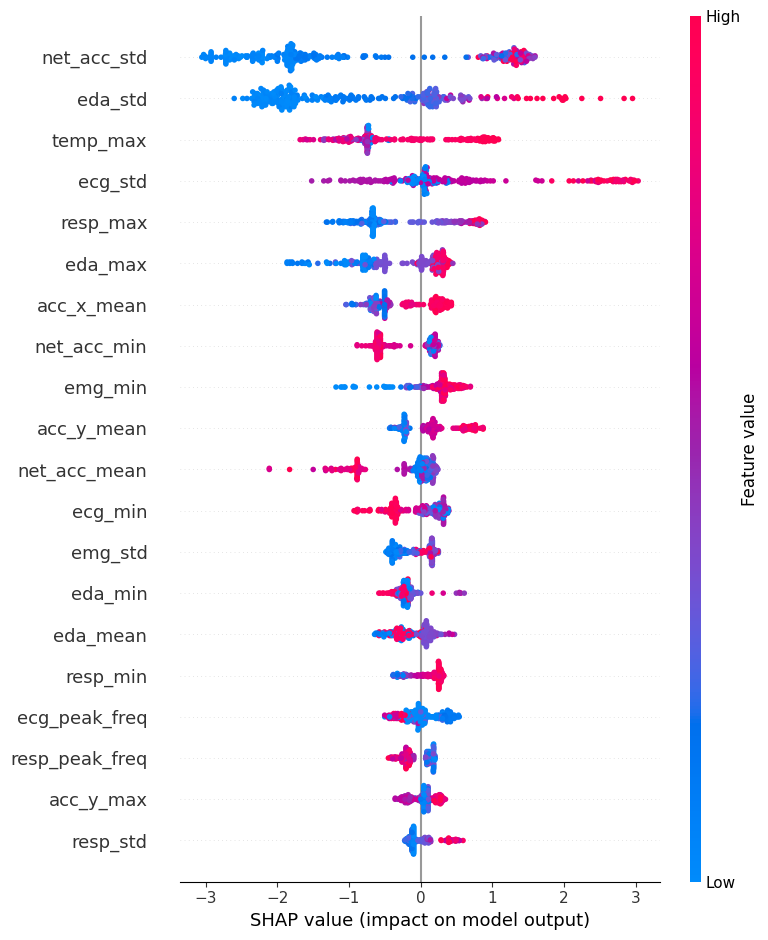

In [17]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

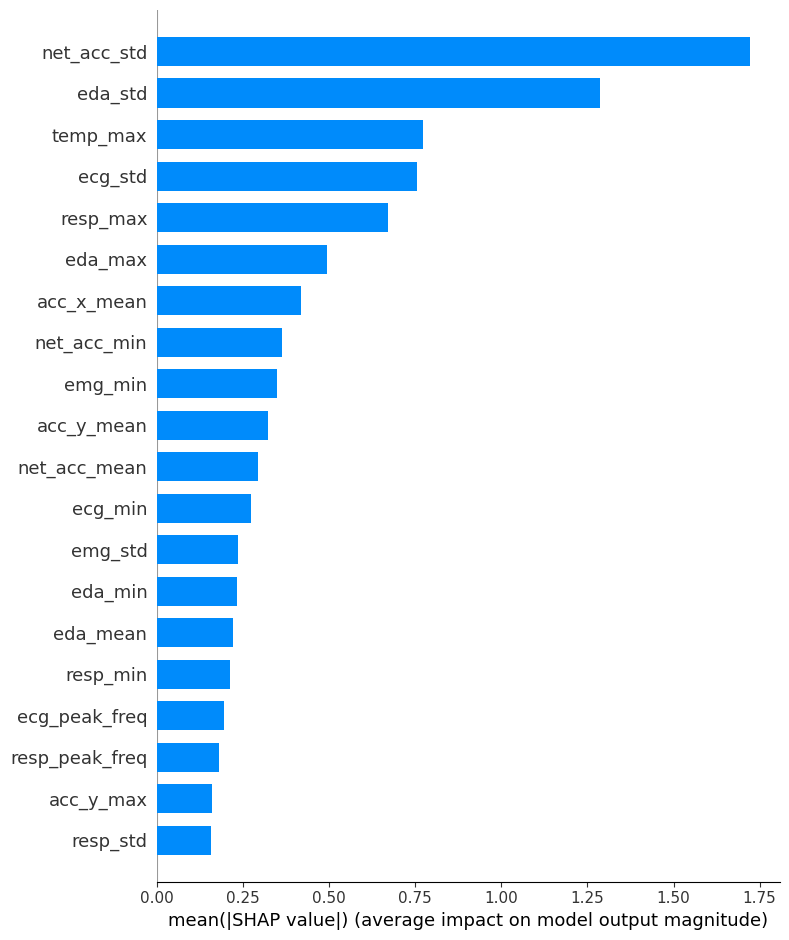

In [18]:
# SHAP bar plot for top features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

## 13. Bias Assessment Summary

In [22]:
print("=" * 60)
print("BIAS ASSESSMENT SUMMARY")
print("=" * 60)

# Data leakage check
print("\n1. DATA LEAKAGE PREVENTION:")
print(f"   - Subject-based train/test split: ✅ IMPLEMENTED")
print(f"   - Subject overlap between sets: {len(train_subs & test_subs)} (should be 0)")

# Class imbalance
print("\n2. CLASS IMBALANCE HANDLING:")
print(f"   - Original imbalance ratio: {df['label'].value_counts()[0] / df['label'].value_counts()[1]:.2f}:1")
print(f"   - SMOTE applied: ✅ YES (1:1 balanced training)")

# Fairness metrics
print("\n3. FAIRNESS METRICS:")
print(f"   - Recall Gap: {recall_gap:.4f} {'✅ PASS' if recall_gap < 0.1 else '⚠️ REVIEW'}")
print(f"   - Precision Gap: {precision_gap:.4f} {'✅ PASS' if precision_gap < 0.1 else '⚠️ REVIEW'}")
print(f"   - Error Rate Gap: {error_gap:.4f} {'✅ PASS' if error_gap < 0.1 else '⚠️ REVIEW'}")

# Overall assessment
print("\n" + "=" * 60)
bias_flags = sum([recall_gap >= 0.1, precision_gap >= 0.1, error_gap >= 0.1])
if bias_flags == 0:
    print("OVERALL: ✅ MODEL SHOWS LOW BIAS RISK")
elif bias_flags == 1:
    print("OVERALL: ⚠️ MODEL SHOWS MODERATE BIAS RISK - Review recommended")
else:
    print("OVERALL: 🚨 MODEL SHOWS HIGH BIAS RISK - Mitigation recommended")
print("=" * 60)

BIAS ASSESSMENT SUMMARY

1. DATA LEAKAGE PREVENTION:
   - Subject-based train/test split: ✅ IMPLEMENTED
   - Subject overlap between sets: 0 (should be 0)

2. CLASS IMBALANCE HANDLING:
   - Original imbalance ratio: 3.52:1
   - SMOTE applied: ✅ YES (1:1 balanced training)

3. FAIRNESS METRICS:
   - Recall Gap: 0.1983 ⚠️ REVIEW
   - Precision Gap: 0.2134 ⚠️ REVIEW
   - Error Rate Gap: 0.1983 ⚠️ REVIEW

OVERALL: 🚨 MODEL SHOWS HIGH BIAS RISK - Mitigation recommended


## 14. Save Model and Results

In [ ]:
import joblib

# Save model
joblib.dump(final_model, 'bias_aware_xgb_model.pkl')
print("Model saved to: bias_aware_xgb_model.pkl")

# Save metrics summary
metrics_summary = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision_class0': tn / (tn + fp),
    'recall_class0': tn / (tn + fn),
    'precision_class1': tp / (tp + fp),
    'recall_class1': tp / (tp + fn),
    'recall_gap': recall_gap,
    'precision_gap': precision_gap,
    'error_gap': error_gap,
    'cv_accuracy_mean': np.mean(cv_scores),
    'cv_accuracy_std': np.std(cv_scores)
}

joblib.dump(metrics_summary, 'metrics_summary.pkl')
print("Metrics saved to: metrics_summary.pkl")

# Display final metrics
print("\n" + "=" * 60)
print("FINAL MODEL METRICS")
print("=" * 60)
for metric, value in metrics_summary.items():
    print(f"{metric:25}: {value:.4f}")